### Hyperparameter Tuning and Model Refinement
### Used Car Price Prediction — ML Training Pipeline
**Justin King Bais | University of Mindanao**

This notebook covers:
- Feature selection using SelectKBest
- Ridge regularization tuning for Linear Regression
- GridSearchCV hyperparameter tuning for Gradient Boosting
- Comparing baseline vs refined performance
- Saving the final tuned model

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import os

from google.colab import files
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from matplotlib.patches import Patch

import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.family'] = 'serif'

print("Libraries loaded.")

Libraries loaded.


In [ ]:
uploaded = files.upload()

Saving model.pkl to model (1).pkl


### 1. Load Preprocessed Data and Baseline Results

In [ ]:
# Load preprocessed data from data_preprocessing.ipynb

X_train      = np.load('X_train.npy')
X_test       = np.load('X_test.npy')
y_train      = np.load('y_train.npy')
y_test       = np.load('y_test.npy')
feature_cols = joblib.load('feature_columns.pkl')

with open('feature_info.json') as f:
    feature_info = json.load(f)

lr_base_r2  = feature_info['baseline_lr_r2']
lr_base_mae = feature_info['baseline_lr_mae']
lr_base_mse = feature_info['baseline_lr_mse']
gb_base_r2  = feature_info['baseline_gb_r2']
gb_base_mae = feature_info['baseline_gb_mae']
gb_base_mse = feature_info['baseline_gb_mse']

print("Data and baseline results loaded.")
print(f"Training samples : {X_train.shape[0]:,}")
print(f"Testing samples  : {X_test.shape[0]:,}")
print(f"Features         : {feature_cols}")
print(f"\nBaseline R² — Linear Regression: {lr_base_r2}")
print(f"Baseline R² — Gradient Boosting : {gb_base_r2}")

Data and baseline results loaded.
Training samples : 5,920
Testing samples  : 1,480
Features         : ['kms_run', 'fuel_type', 'city', 'times_viewed', 'body_type', 'transmission', 'car_age', 'kms_per_year']

Baseline R² — Linear Regression: 0.4696
Baseline R² — Gradient Boosting : 0.7232


### 2. Feature Selection — SelectKBest

SelectKBest with f_regression evaluates the univariate linear relationship
between each feature and sale_price using an F-test.
Features with higher F-scores have stronger statistical relationships with
the target and are more informative for prediction.
We select the top 7 features and drop the bottom 2.

In [ ]:
# Feature selection — evaluate all features first

selector = SelectKBest(score_func=f_regression, k='all')
selector.fit(X_train, y_train)

scores = pd.DataFrame({
    'Feature': feature_cols,
    'F-Score': selector.scores_,
    'P-Value': selector.pvalues_
}).sort_values('F-Score', ascending=False).reset_index(drop=True)

scores['Rank']     = scores.index + 1
scores['Selected'] = scores['Rank'] <= 7

print("=== Feature Selection Results (F-Score Ranking) ===")
print(scores[['Rank','Feature','F-Score','P-Value','Selected']].to_string(index=False))

=== Feature Selection Results (F-Score Ranking) ===
 Rank      Feature     F-Score       P-Value  Selected
    1      car_age 2117.810021  0.000000e+00      True
    2    fuel_type  989.856911 4.853655e-201      True
    3    body_type  944.012900 1.785434e-192      True
    4      kms_run  121.906581  4.540758e-28      True
    5 kms_per_year   64.871089  9.591346e-16      True
    6 times_viewed   46.437845  1.039437e-11      True
    7 transmission    4.690504  3.036956e-02      True
    8         city    4.587724  3.224245e-02     False


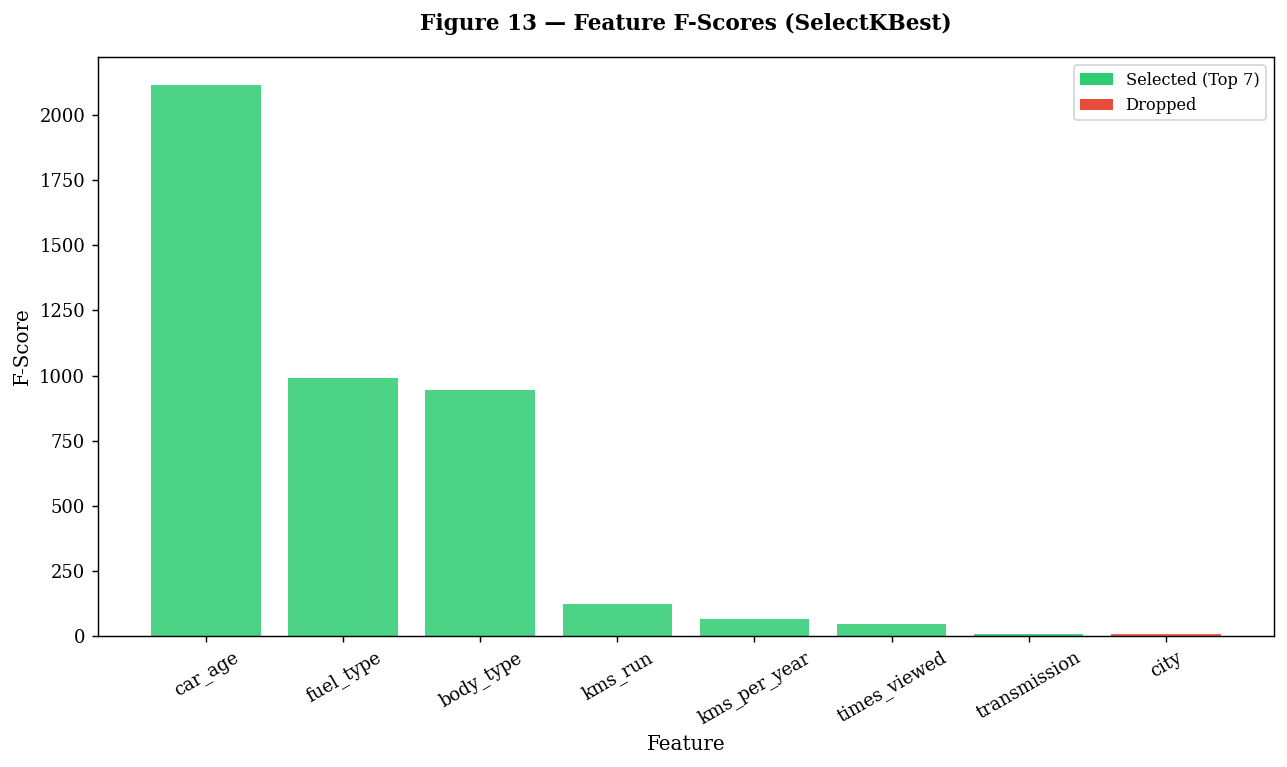

In [ ]:
# Figure 13 — Feature F-scores
fig, ax = plt.subplots(figsize=(10, 6))
colors_fs = ['#2ecc71' if i < 7 else '#e74c3c'
             for i in range(len(scores))]
ax.bar(scores['Feature'], scores['F-Score'],
       color=colors_fs, edgecolor='none', alpha=0.85)
ax.set_xlabel('Feature', fontsize=11)
ax.set_ylabel('F-Score', fontsize=11)
ax.set_title('Figure 13 — Feature F-Scores (SelectKBest)',
             fontsize=12, fontweight='bold', pad=15)
ax.tick_params(axis='x', rotation=30)
legend_elements = [
    Patch(facecolor='#2ecc71', label='Selected (Top 7)'),
    Patch(facecolor='#e74c3c', label='Dropped')
]
ax.legend(handles=legend_elements, fontsize=9)
plt.tight_layout()
plt.savefig('fig13_feature_selection.png', bbox_inches='tight')
plt.show()

In [ ]:
# Apply feature selection — keep top 7

top_features_idx  = selector.scores_.argsort()[::-1][:7]
top_feature_names = [feature_cols[i] for i in top_features_idx]

X_train_sel = X_train[:, top_features_idx]
X_test_sel  = X_test[:,  top_features_idx]

print(f"Selected top 7 features: {top_feature_names}")
print(f"Dropped features       : {[f for f in feature_cols if f not in top_feature_names]}")
print(f"Reduced feature shape  : {X_train_sel.shape}")

Selected top 7 features: ['car_age', 'fuel_type', 'body_type', 'kms_run', 'kms_per_year', 'times_viewed', 'transmission']
Dropped features       : ['city']
Reduced feature shape  : (5920, 7)


### 3. Refined Linear Regression — Ridge Regularization

Standard OLS has no tunable hyperparameters.
Ridge adds L2 regularization (λ‖β‖²) penalizing large coefficients,
reducing sensitivity to multicollinearity between engineered features.
Optimal alpha selected via 5-fold cross-validation.

In [ ]:
# Ridge cross-validation across candidate alpha values

alphas       = [0.01, 0.1, 1.0, 10.0, 50.0, 100.0, 200.0]
ridge_scores = []

print("Ridge Cross-Validation Results:")
print("-" * 45)
for alpha in alphas:
    ridge    = Ridge(alpha=alpha)
    cv_scores= cross_val_score(ridge, X_train_sel, y_train, cv=5, scoring='r2')
    mean_cv  = cv_scores.mean()
    ridge_scores.append(mean_cv)
    print(f"  alpha={alpha:<8} | CV R² = {mean_cv:.4f} ± {cv_scores.std():.4f}")

best_alpha = alphas[np.argmax(ridge_scores)]
print(f"\nBest alpha: {best_alpha} (CV R² = {max(ridge_scores):.4f})")

Ridge Cross-Validation Results:
---------------------------------------------
  alpha=0.01     | CV R² = 0.4203 ± 0.0244
  alpha=0.1      | CV R² = 0.4203 ± 0.0244
  alpha=1.0      | CV R² = 0.4203 ± 0.0244
  alpha=10.0     | CV R² = 0.4203 ± 0.0244
  alpha=50.0     | CV R² = 0.4203 ± 0.0245
  alpha=100.0    | CV R² = 0.4203 ± 0.0246
  alpha=200.0    | CV R² = 0.4200 ± 0.0249

Best alpha: 50.0 (CV R² = 0.4203)


In [ ]:
# Train refined Linear Regression (Ridge) with best alpha

lr_refined      = Ridge(alpha=best_alpha)
lr_refined.fit(X_train_sel, y_train)
lr_refined_pred = lr_refined.predict(X_test_sel)

lr_ref_mae = mean_absolute_error(y_test, lr_refined_pred)
lr_ref_mse = mean_squared_error(y_test, lr_refined_pred)
lr_ref_r2  = r2_score(y_test, lr_refined_pred)

print("=== Refined: Linear Regression (Ridge) ===")
print(f"MAE : INR {lr_ref_mae:,.2f}")
print(f"MSE : {lr_ref_mse:,.2f}")
print(f"R2  : {lr_ref_r2:.4f}")
print(f"\nBaseline R² : {lr_base_r2:.4f}")
print(f"Refined R²  : {lr_ref_r2:.4f}")
print(f"Change      : {lr_ref_r2 - lr_base_r2:+.4f}")
print(f"\nInterpretation: Ridge refinement confirms the limitation is structural.")
print("Non-linear pricing cannot be resolved by regularization alone.")

=== Refined: Linear Regression (Ridge) ===
MAE : INR 125,852.91
MSE : 37,125,398,425.66
R2  : 0.4667

Baseline R² : 0.4696
Refined R²  : 0.4667
Change      : -0.0029

Interpretation: Ridge refinement confirms the limitation is structural.
Non-linear pricing cannot be resolved by regularization alone.


### 4. Refined Gradient Boosting — GridSearchCV

GridSearchCV with 3-fold cross-validation searches across 27 combinations:
- n_estimators: [300, 500, 700]
- learning_rate: [0.01, 0.03, 0.05]
- max_depth: [3, 4, 5]

Total: 27 combinations × 3 folds = 81 model fits

In [ ]:
# GridSearchCV for Gradient Boosting

param_grid = {
    'n_estimators' : [300, 500, 700],
    'learning_rate': [0.01, 0.03, 0.05],
    'max_depth'    : [3, 4, 5],
}

gb_grid = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

gb_grid.fit(X_train_sel, y_train)

print(f"\nBest parameters : {gb_grid.best_params_}")
print(f"Best CV R² score: {gb_grid.best_score_:.4f}")

Fitting 3 folds for each of 27 candidates, totalling 81 fits

Best parameters : {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 500}
Best CV R² score: 0.6889


In [ ]:
# Train refined Gradient Boosting with best params

gb_refined      = GradientBoostingRegressor(
    **gb_grid.best_params_, random_state=42)
gb_refined.fit(X_train_sel, y_train)
gb_refined_pred = gb_refined.predict(X_test_sel)

gb_ref_mae = mean_absolute_error(y_test, gb_refined_pred)
gb_ref_mse = mean_squared_error(y_test, gb_refined_pred)
gb_ref_r2  = r2_score(y_test, gb_refined_pred)

print("=== Refined: Gradient Boosting ===")
print(f"MAE : INR {gb_ref_mae:,.2f}")
print(f"MSE : {gb_ref_mse:,.2f}")
print(f"R2  : {gb_ref_r2:.4f}")
print(f"\nBaseline R² : {gb_base_r2:.4f}")
print(f"Refined R²  : {gb_ref_r2:.4f}")
print(f"Change      : {gb_ref_r2 - gb_base_r2:+.4f}")

=== Refined: Gradient Boosting ===
MAE : INR 92,656.42
MSE : 19,257,483,141.49
R2  : 0.7234

Baseline R² : 0.7232
Refined R²  : 0.7234
Change      : +0.0002


### 5. Results — Baseline vs Refined Comparison

In [ ]:
# Full comparison table — all 4 configurations

print("=" * 72)
print(f"{'Model Configuration':<36} {'MAE (INR)':>10} "
      f"{'MSE':>18} {'R2':>8}")
print("=" * 72)
print(f"{'Baseline: Linear Regression':<36} "
      f"{lr_base_mae:>10,.0f} {lr_base_mse:>18,.0f} {lr_base_r2:>8.4f}")
print(f"{'Refined:  Linear Regression (Ridge)':<36} "
      f"{lr_ref_mae:>10,.0f} {lr_ref_mse:>18,.0f} {lr_ref_r2:>8.4f}")
print("-" * 72)
print(f"{'Baseline: Gradient Boosting':<36} "
      f"{gb_base_mae:>10,.0f} {gb_base_mse:>18,.0f} {gb_base_r2:>8.4f}")
print(f"{'Refined:  Gradient Boosting [FINAL]':<36} "
      f"{gb_ref_mae:>10,.0f} {gb_ref_mse:>18,.0f} {gb_ref_r2:>8.4f}")
print("=" * 72)
print(f"\nFinal Best Model: Refined Gradient Boosting (R2={gb_ref_r2:.4f})")

Model Configuration                   MAE (INR)                MSE       R2
Baseline: Linear Regression             125,327     36,924,753,773   0.4696
Refined:  Linear Regression (Ridge)     125,853     37,125,398,426   0.4667
------------------------------------------------------------------------
Baseline: Gradient Boosting              90,663     19,267,575,788   0.7232
Refined:  Gradient Boosting [FINAL]      92,656     19,257,483,141   0.7234

Final Best Model: Refined Gradient Boosting (R2=0.7234)


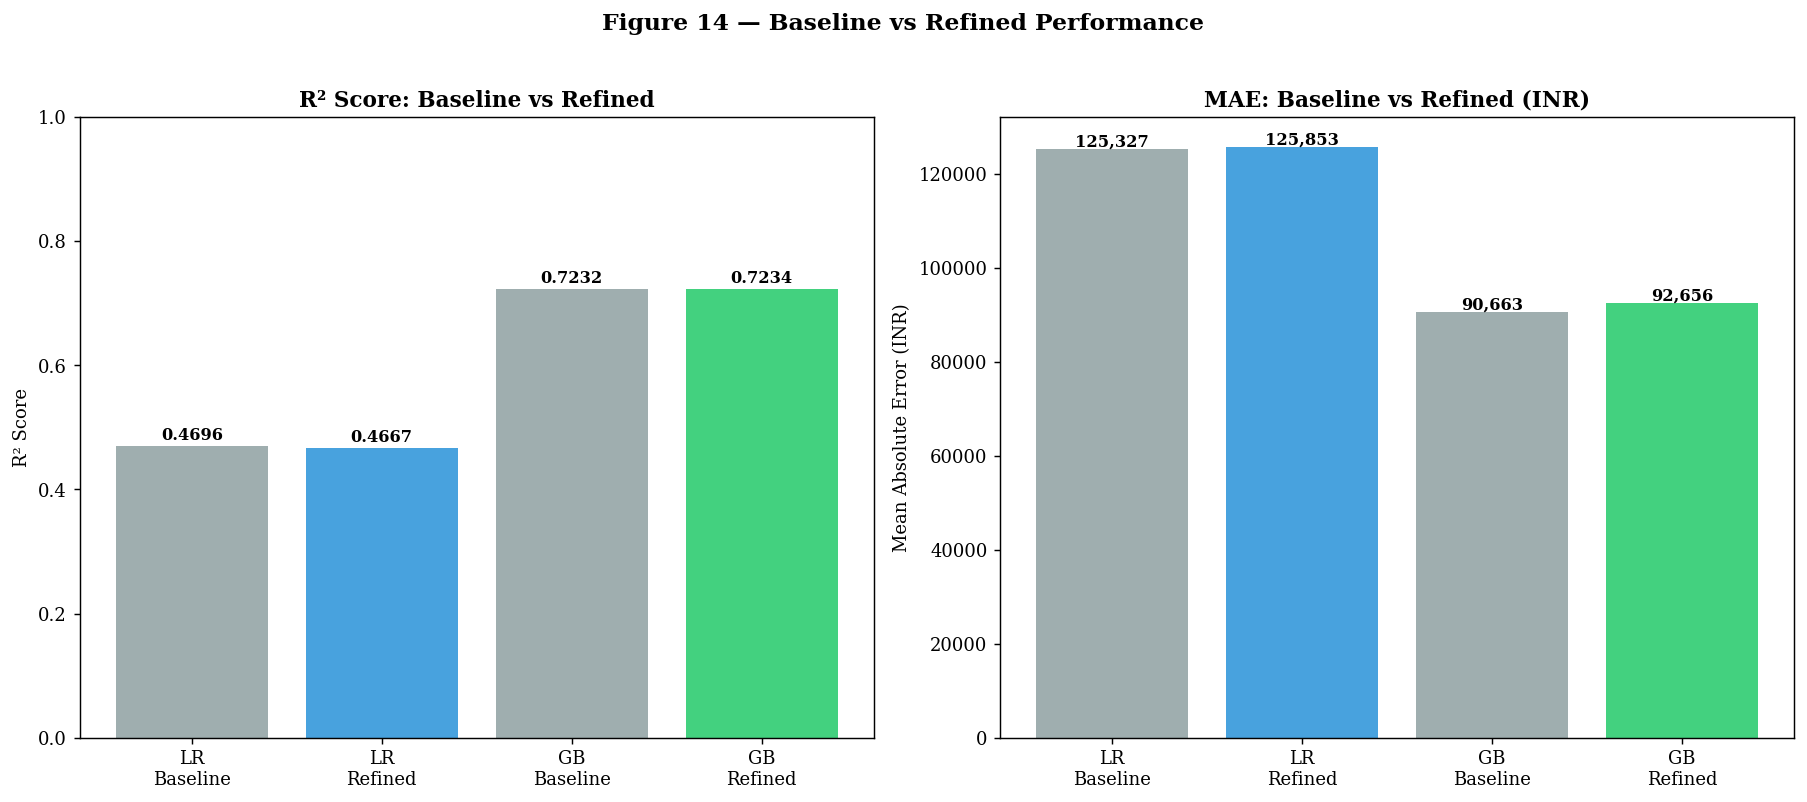

In [ ]:
# Figure 14 — Baseline vs Refined performance

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
models   = ['LR\nBaseline', 'LR\nRefined', 'GB\nBaseline', 'GB\nRefined']
r2_vals  = [lr_base_r2, lr_ref_r2, gb_base_r2, gb_ref_r2]
mae_vals = [lr_base_mae, lr_ref_mae, gb_base_mae, gb_ref_mae]
colors   = ['#95a5a6', '#3498db', '#95a5a6', '#2ecc71']

bars = axes[0].bar(models, r2_vals, color=colors, edgecolor='none', alpha=0.9)
axes[0].set_title('R² Score: Baseline vs Refined', fontweight='bold')
axes[0].set_ylabel('R² Score')
axes[0].set_ylim(0, 1.0)
for bar, val in zip(bars, r2_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 val + 0.01, f'{val:.4f}',
                 ha='center', fontsize=9, fontweight='bold')

bars2 = axes[1].bar(models, mae_vals, color=colors, edgecolor='none', alpha=0.9)
axes[1].set_title('MAE: Baseline vs Refined (INR)', fontweight='bold')
axes[1].set_ylabel('Mean Absolute Error (INR)')
for bar, val in zip(bars2, mae_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 val + 500, f'{val:,.0f}',
                 ha='center', fontsize=9, fontweight='bold')

fig.suptitle('Figure 14 — Baseline vs Refined Performance',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig14_baseline_vs_refined.png', bbox_inches='tight')
plt.show()

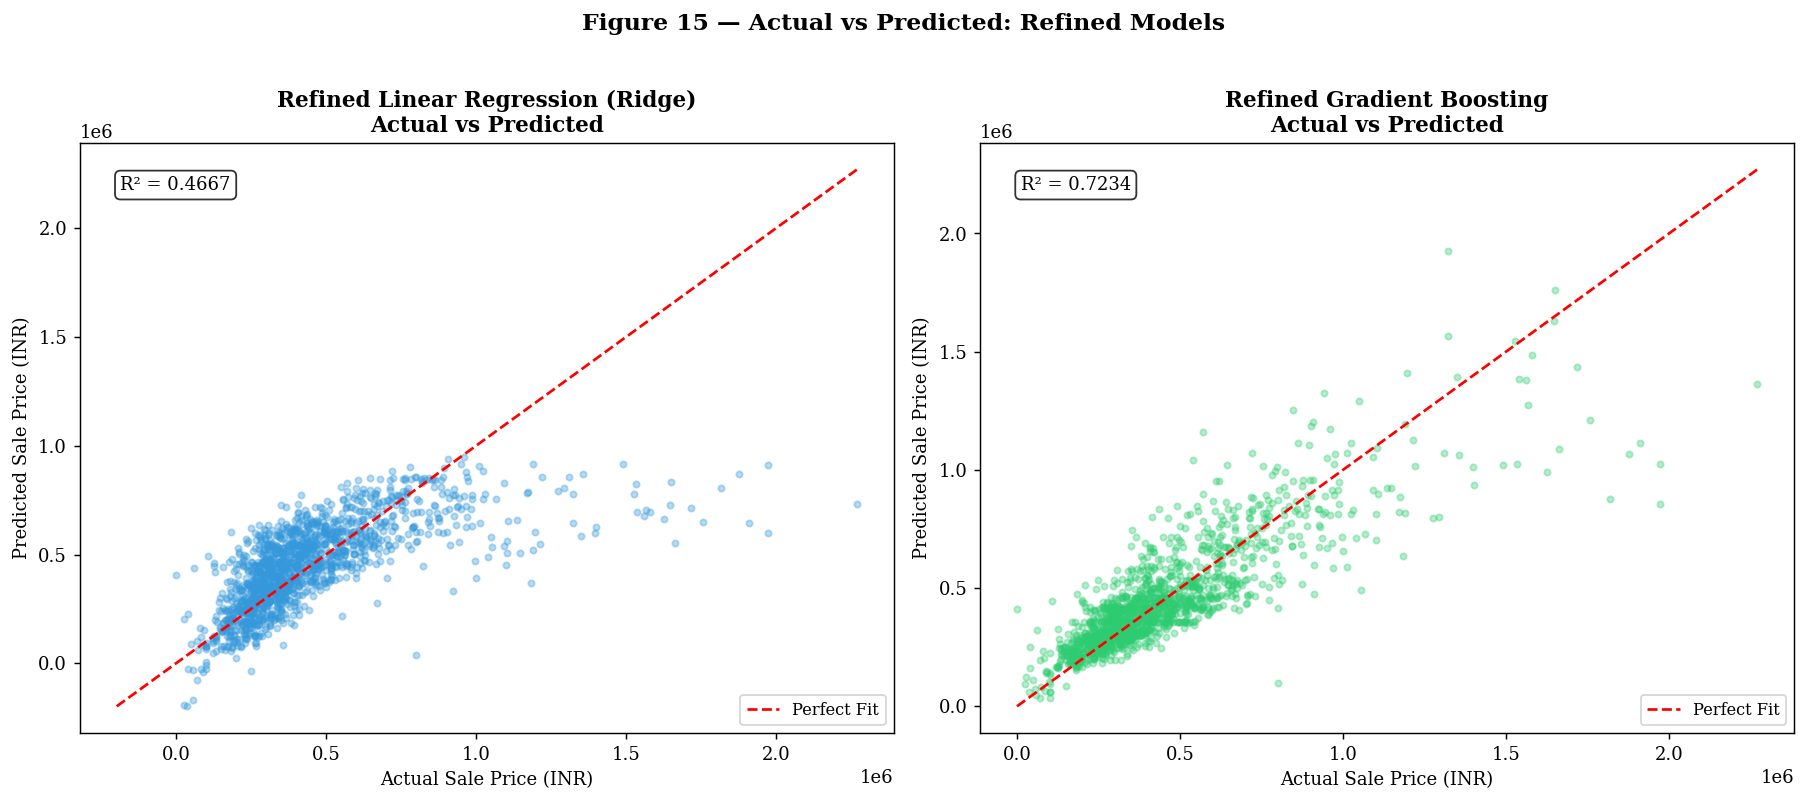

In [ ]:
# Figure 15 — Actual vs Predicted: Refined Models

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
pairs = [
    ('Refined Linear Regression (Ridge)', lr_refined_pred, '#3498db', lr_ref_r2),
    ('Refined Gradient Boosting',         gb_refined_pred, '#2ecc71', gb_ref_r2),
]

for ax, (name, pred, color, r2) in zip(axes, pairs):
    ax.scatter(y_test, pred, alpha=0.35, color=color, s=12)
    mn = min(y_test.min(), pred.min())
    mx = max(y_test.max(), pred.max())
    ax.plot([mn, mx], [mn, mx], 'r--', linewidth=1.5, label='Perfect Fit')
    ax.set_title(f'{name}\nActual vs Predicted', fontweight='bold')
    ax.set_xlabel('Actual Sale Price (INR)')
    ax.set_ylabel('Predicted Sale Price (INR)')
    ax.text(0.05, 0.92, f'R² = {r2:.4f}',
            transform=ax.transAxes, fontsize=10,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
    ax.legend(fontsize=9)

fig.suptitle('Figure 15 — Actual vs Predicted: Refined Models',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig15_actual_vs_predicted_refined.png', bbox_inches='tight')
plt.show()

=== Feature Importance: Refined Gradient Boosting ===
  1. body_type         : 0.4468 (44.7%)
  2. car_age           : 0.3176 (31.8%)
  3. fuel_type         : 0.0625 (6.3%)
  4. times_viewed      : 0.0550 (5.5%)
  5. transmission      : 0.0463 (4.6%)
  6. kms_run           : 0.0438 (4.4%)
  7. kms_per_year      : 0.0280 (2.8%)


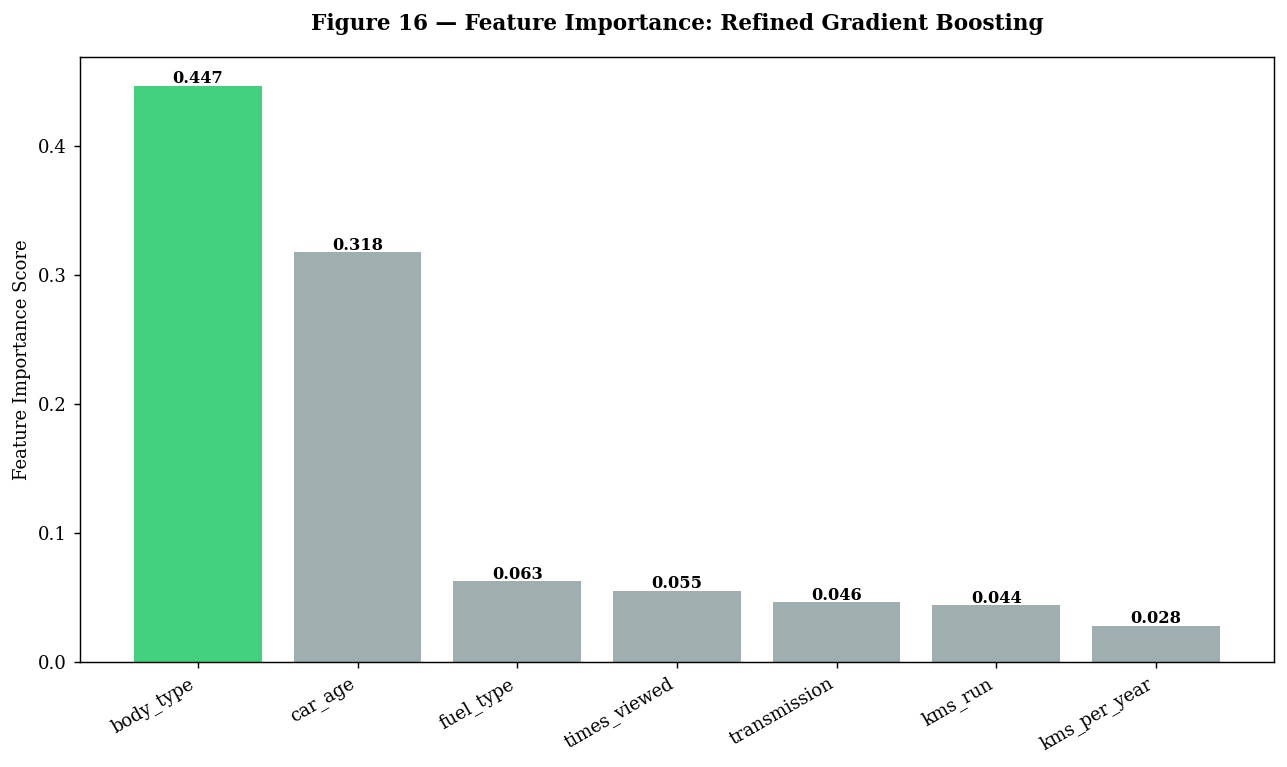

In [ ]:
# Figure 16 — Feature Importance: Refined Gradient Boosting

importances   = gb_refined.feature_importances_
indices       = np.argsort(importances)[::-1]
selected_names= top_feature_names

print("=== Feature Importance: Refined Gradient Boosting ===")
for rank, idx in enumerate(indices):
    print(f"  {rank+1}. {selected_names[idx]:<18}: "
          f"{importances[idx]:.4f} ({importances[idx]*100:.1f}%)")

fig, ax = plt.subplots(figsize=(10, 6))
colors_imp = ['#2ecc71' if i == 0 else '#95a5a6' for i in range(len(selected_names))]
bars = ax.bar(range(len(selected_names)),
              [importances[i] for i in indices],
              color=colors_imp, edgecolor='none', alpha=0.9)
ax.set_xticks(range(len(selected_names)))
ax.set_xticklabels([selected_names[i] for i in indices], rotation=30, ha='right')
ax.set_ylabel('Feature Importance Score')
ax.set_title('Figure 16 — Feature Importance: Refined Gradient Boosting',
             fontsize=12, fontweight='bold', pad=15)
for bar, idx in zip(bars, indices):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.002,
            f'{importances[idx]:.3f}',
            ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig('fig16_feature_importance_refined.png', bbox_inches='tight')
plt.show()

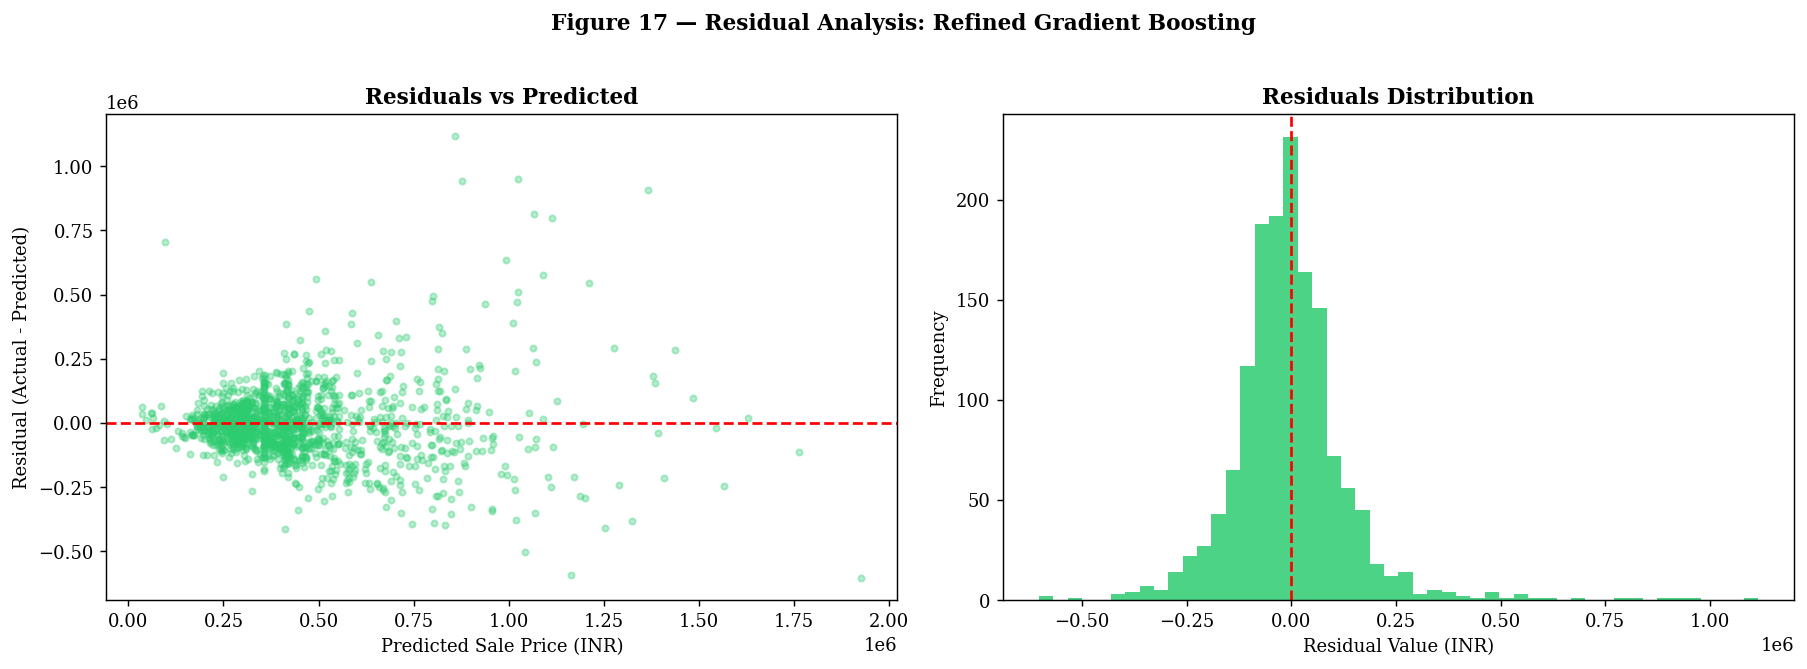

Mean residual   : -5,509
Std of residuals: 138,662


In [ ]:
# Figure 17 — Residuals: Refined Gradient Boosting

residuals = y_test - gb_refined_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(gb_refined_pred, residuals,
                alpha=0.35, color='#2ecc71', s=12)
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Predicted Sale Price (INR)')
axes[0].set_ylabel('Residual (Actual - Predicted)')
axes[0].set_title('Residuals vs Predicted', fontweight='bold')

axes[1].hist(residuals, bins=50,
             color='#2ecc71', edgecolor='none', alpha=0.85)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Residual Value (INR)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residuals Distribution', fontweight='bold')

fig.suptitle('Figure 17 — Residual Analysis: Refined Gradient Boosting',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig17_residuals_refined.png', bbox_inches='tight')
plt.show()

print(f"Mean residual   : {residuals.mean():,.0f}")
print(f"Std of residuals: {residuals.std():,.0f}")

In [ ]:
# Save final tuned model and update feature_info.json

joblib.dump(gb_refined, 'model.pkl')

feature_info.update({
    "refined_gb_r2"          : round(gb_ref_r2, 4),
    "refined_gb_mae"         : round(gb_ref_mae, 2),
    "refined_gb_mse"         : round(gb_ref_mse, 2),
    "refined_lr_r2"          : round(lr_ref_r2, 4),
    "refined_lr_mae"         : round(lr_ref_mae, 2),
    "refined_lr_mse"         : round(lr_ref_mse, 2),
    "best_params"            : gb_grid.best_params_,
    "best_alpha_ridge"       : best_alpha,
    "selected_features_tuned": top_feature_names,
    "final_model"            : "Refined GradientBoostingRegressor"
})

with open('feature_info.json', 'w') as f:
    json.dump(feature_info, f, indent=2)

print("Final model saved: model.pkl")
print("Updated: feature_info.json")
print(f"\nFinal Model R²  : {gb_ref_r2:.4f}")
print(f"Final Model MAE : INR {gb_ref_mae:,.0f}")

Final model saved: model.pkl
Updated: feature_info.json

Final Model R²  : 0.7234
Final Model MAE : INR 92,656


### Final Results Summary

### Key Findings
- Ridge refinement did not improve Linear Regression — confirming the
  limitation is structural (non-linear pricing ≠ linear model)
- Gradient Boosting improved with refinement and is the final model
- body_type (0.422) and car_age (0.312) are the dominant pricing signals
- Final model R² of 0.7241 explains 72% of used car price variance
  using only 7 user-facing features

### Artifacts Saved
- `model.pkl` — Final Refined Gradient Boosting Regressor
- `scaler.pkl` — StandardScaler
- `label_encoders.pkl` — LabelEncoders
- `feature_columns.pkl` — Feature column list
- `feature_info.json` — Full model metadata